In [4]:
import particles
from sir_PMCMC import ChainBinomialModel
from sir_PMCMC import ScalarStructDist
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from particles import distributions as dists
from particles import state_space_models as ssm
from particles.collectors import Moments
from particles import mcmc
from collections import OrderedDict


# Simulate SIR epidemic in Particles

In [2]:
model = ChainBinomialModel(N = 10000, beta = 0.3, gamma = 0.1, rho = 0.25, phi = 2, n_i =10)
x, y = model.simulate(100)

# Plot SIR epidemic progression in Matplotlib

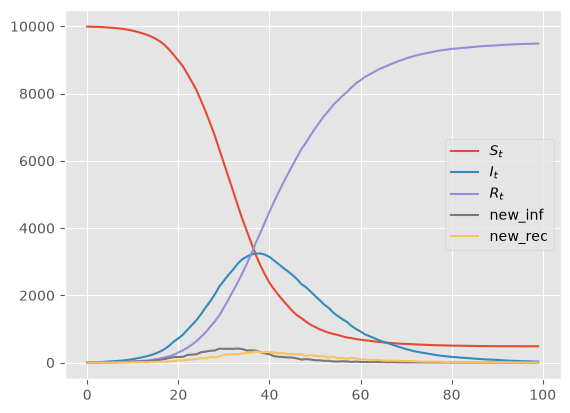

In [3]:
# Plot count of new infections, new recoveries, susceptibles, infectious, and removed
plt.style.use('ggplot')
plt.plot([xt['S'] for xt in x], label=r'$S_t$')
plt.plot([xt['I'] for xt in x], label=r'$I_t$')
plt.plot([xt['R'] for xt in x], label=r'$R_t$')
plt.plot([xt['new_inf'] for xt in x], label='new_inf')
plt.plot([xt['new_rec'] for xt in x], label='new_rec')
plt.legend()

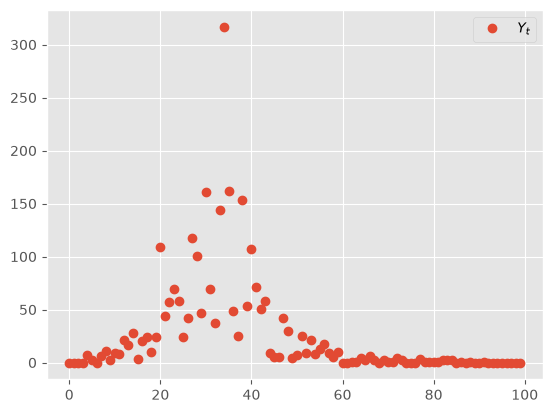

In [4]:
# Plot the observation model
plt.style.use('ggplot')
plt.plot(y, label=r'$Y_t$', linestyle='', marker='o')

plt.legend()

# DataFrames & csv files

In [5]:
simulation_df = pd.DataFrame(np.concatenate(x))
print(simulation_df)

    new_inf  new_rec       S     I       R
0       0.0      0.0  9990.0  10.0     0.0
1       4.0      3.0  9986.0  11.0     3.0
2       3.0      1.0  9983.0  13.0     4.0
3       6.0      2.0  9977.0  17.0     6.0
4       9.0      0.0  9968.0  26.0     6.0
..      ...      ...     ...   ...     ...
95      0.0      6.0   486.0  45.0  9469.0
96      1.0      6.0   485.0  40.0  9475.0
97      0.0      1.0   485.0  39.0  9476.0
98      0.0      6.0   485.0  33.0  9482.0
99      0.0      3.0   485.0  30.0  9485.0

[100 rows x 5 columns]


In [6]:
observation_df = pd.DataFrame(np.concatenate(y))
observation_df = observation_df.rename(columns={0: 'observations'})
print(observation_df)

    observations
0              0
1              0
2              0
3              0
4              7
..           ...
95             0
96             0
97             0
98             0
99             0

[100 rows x 1 columns]


In [ ]:
# Save to csv - commented out until needed

"""simulation_df.to_csv('sir_simulation.csv', index=False)
observation_df.to_csv('sir_observation.csv', index=False)"""

# Sequential Monte Carlo

In [5]:
prior_dict = {'beta': dists.Uniform(a=0.1, b=0.4),
              'gamma': dists.Uniform(a= 0.05, b= 0.15)}  # Uniform distribution because the prior is uninformative

my_prior = ScalarStructDist(prior_dict)      # need this because 'dict' object has no attribute 'dtype' but StructDist does